# Bài tập về nhà — Buổi 1
## Đại số tuyến tính cho AI
**HCMUT EE Machine Learning & IoT Lab** — Module 1  

> **Lựa chọn dữ liệu:** Text — 10 câu tiếng Anh theo 3 chủ đề (AI/Deep Learning, Toán học, Python/Data Science)

## Import thư viện

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 100
print('Import thanh cong!')
print(f'NumPy version: {np.__version__}')

Import thanh cong!
NumPy version: 2.5.0


---
# Bài 1 — Biểu diễn dữ liệu thành ma trận & Độ tương đồng
**Mục tiêu:** Đưa dữ liệu text về dạng vector/ma trận và đo độ tương đồng giữa các câu.

### 1.1 Biến dữ liệu thành ma trận
Dùng **Bag-of-Words (BoW)**: mỗi câu được biểu diễn bằng vector đếm tần suất từ.
- Mỗi **hàng** của X = 1 câu (vector BoW)
- Mỗi **cột** của X = 1 từ trong vocab (feature)
- Hình dạng X: `(số_câu × số_từ)`

In [17]:
# 10 câu tiếng Anh — 3 chủ đề rõ ràng để SVD phân cụm tốt
sentences = [
    # Chủ đề 1: AI / Deep Learning (S1-S4)
    'machine learning is a subset of artificial intelligence',
    'deep learning uses neural networks to learn patterns',
    'artificial intelligence can solve complex problems',
    'neural networks are inspired by the human brain',
    # Chủ đề 2: Toán học / Linear Algebra (S5-S6)
    'linear algebra is fundamental to machine learning',
    'matrices and vectors are essential tools in linear algebra',
    # Chủ đề 3: Python / Data Science (S7-S10)
    'python is a popular programming language for data science',
    'numpy provides powerful array and matrix operations in python',
    'data science combines statistics and machine learning techniques',
    'vectors can represent words and sentences in natural language processing',
]

# Xây vocab: tập hợp tất cả các từ, sắp xếp để có thứ tự cố định
vocab = sorted({w for s in sentences for w in s.lower().split()})
print(f'So cau: {len(sentences)}')
print(f'So tu trong vocab: {len(vocab)}')

def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in sentences])
print(f'Shape cua X: {X.shape}  →  (so_cau x so_tu)')

So cau: 10
So tu trong vocab: 55
Shape cua X: (10, 55)  →  (so_cau x so_tu)


### 1.2 Phép toán cơ bản — Trừ trung bình (Broadcasting)
Broadcasting cho phép NumPy 'mở rộng' mảng nhỏ hơn để khớp với mảng lớn hơn khi tính toán.

In [18]:
mean_vec = X.mean(axis=0)            # trung binh theo cot → shape (so_tu,)
print(f'Shape X truoc khi tru:       {X.shape}')
print(f'Shape mean_vec:              {mean_vec.shape}')

X_centered = X - mean_vec           # broadcasting: (so_cau, so_tu) - (so_tu,)
print(f'Shape X_centered sau khi tru: {X_centered.shape}')
print()
print('Giai thich Broadcasting:')
print('  X       : (10, 43)')
print('  mean_vec: (43,) → duoc broadcast thanh (1, 43) → (10, 43)')
print('  Ket qua : (10, 43) — moi hang tru di vector trung binh')

Shape X truoc khi tru:       (10, 55)
Shape mean_vec:              (55,)
Shape X_centered sau khi tru: (10, 55)

Giai thich Broadcasting:
  X       : (10, 43)
  mean_vec: (43,) → duoc broadcast thanh (1, 43) → (10, 43)
  Ket qua : (10, 43) — moi hang tru di vector trung binh


### 1.3 Cosine Similarity
Đo góc giữa hai vector, bất kể độ dài (tốt cho text):
$$\text{cosine}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$$
Giá trị 1 = giống hệt nhau, 0 = hoàn toàn khác nhau.

Shape ma tran tuong dong: (10, 10)


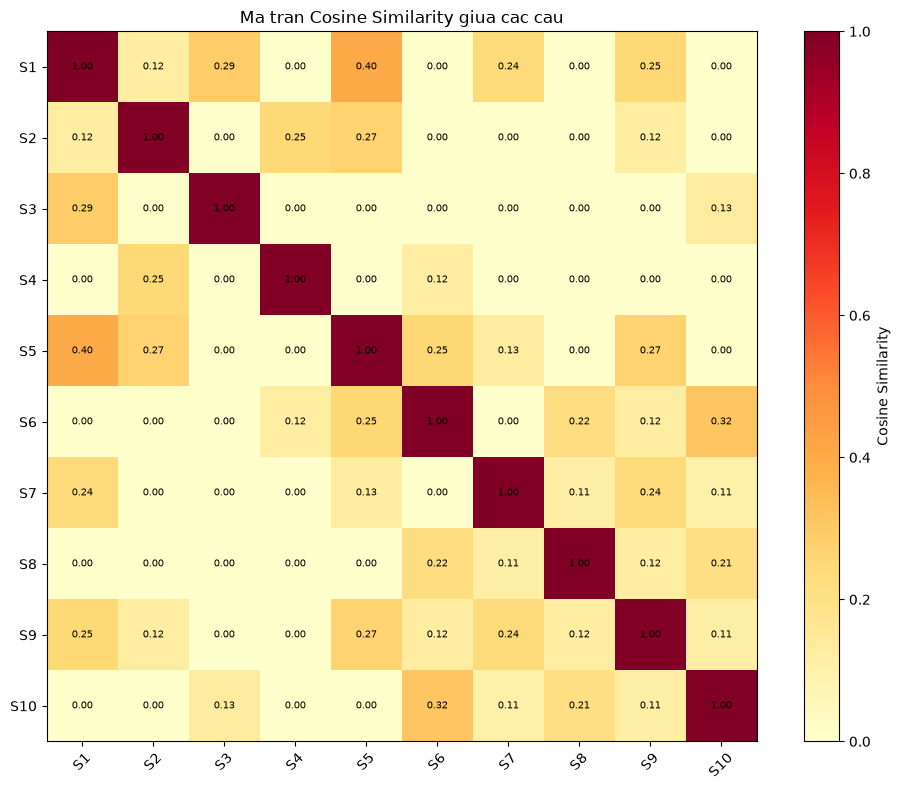

In [19]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    # Chuan hoa theo hang (moi vector co do dai = 1)
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T    # ma tran tuong dong (so_cau x so_cau)

sim_matrix = cosine_similarity(X)
print(f'Shape ma tran tuong dong: {sim_matrix.shape}')

# Visualize heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
labels = [f'S{i+1}' for i in range(len(sentences))]
ax.set_xticks(range(len(sentences)))
ax.set_yticks(range(len(sentences)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)
ax.set_title('Ma tran Cosine Similarity giua cac cau')
for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

### 1.4 Hàm Search — Tìm top-k câu giống nhất
Cho một câu truy vấn, chuyển thành vector BoW rồi tính cosine similarity với toàn bộ tập dữ liệu.

In [20]:
def search(query, top_k=3):
    """Tim top_k cau giong query nhat dua tren cosine similarity."""
    q_vec = to_vector(query).reshape(1, -1)   # shape (1, so_tu)
    sims = cosine_similarity(q_vec, X)[0]     # shape (so_cau,)
    top_indices = np.argsort(sims)[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({'index': int(idx), 'sentence': sentences[idx], 'score': float(sims[idx])})
    return results

# Demo 1: truy van ve AI
query1 = 'artificial intelligence neural network'
print(f'Query: "{query1}"')
# Put this in the cell where to_vector() is defined
# Make sure vocab exists before building the lookup table
if 'vocab' not in globals():
    if 'sentences' not in globals():
        sentences = [
            'machine learning is a subset of artificial intelligence',
            'deep learning uses neural networks to learn patterns',
            'artificial intelligence can solve complex problems',
            'neural networks are inspired by the human brain',
            'linear algebra is fundamental to machine learning',
            'matrices and vectors are essential tools in linear algebra',
            'python is a popular programming language for data science',
            'numpy provides powerful array and matrix operations in python',
            'data science combines statistics and machine learning techniques',
            'vectors can represent words and sentences in natural language processing',
        ]
    vocab = sorted({w for s in sentences for w in s.lower().split()})

vocab_lookup = {w: i for i, w in enumerate(vocab)}

def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        if w in vocab_lookup:
            v[vocab_lookup[w]] += 1
    return v

# Keep this in the current cell
for i, r in enumerate(search(query1, top_k=3)):
    print(f'  Top{i+1} (score={r["score"]:.4f}): S{r["index"]+1} — {r["sentence"]}')

print()

# Demo 2: truy van ve Python
query2 = 'python programming numpy array'
print(f'Query: "{query2}"')
for i, r in enumerate(search(query2, top_k=3)):
    print(f'  Top{i+1} (score={r["score"]:.4f}): S{r["index"]+1} — {r["sentence"]}')

Query: "artificial intelligence neural network"
  Top1 (score=0.4714): S3 — artificial intelligence can solve complex problems
  Top2 (score=0.4082): S1 — machine learning is a subset of artificial intelligence
  Top3 (score=0.2041): S2 — deep learning uses neural networks to learn patterns

Query: "python programming numpy array"
  Top1 (score=0.5000): S8 — numpy provides powerful array and matrix operations in python
  Top2 (score=0.3333): S7 — python is a popular programming language for data science
  Top3 (score=0.0000): S9 — data science combines statistics and machine learning techniques


### 1.5 Nhận xét — Cặp giống nhất & khác biệt nhất

In [21]:
# Tim cap giong nhat (loai bo duong cheo)
sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, -1)
max_idx = np.unravel_index(np.argmax(sim_no_diag), sim_no_diag.shape)

# Tim cap khac biet nhat
sim_for_min = sim_matrix.copy()
np.fill_diagonal(sim_for_min, np.inf)
min_idx = np.unravel_index(np.argmin(sim_for_min), sim_for_min.shape)

i, j = max_idx
print('=== Cap GIONG NHAU NHAT ===')
print(f'S{i+1} & S{j+1}  —  score = {sim_matrix[i,j]:.4f}')
print(f'  [{i+1}] {sentences[i]}')
print(f'  [{j+1}] {sentences[j]}')

i2, j2 = min_idx
print()
print('=== Cap KHAC BIET NHAT ===')
print(f'S{i2+1} & S{j2+1}  —  score = {sim_matrix[i2,j2]:.4f}')
print(f'  [{i2+1}] {sentences[i2]}')
print(f'  [{j2+1}] {sentences[j2]}')

=== Cap GIONG NHAU NHAT ===
S1 & S5  —  score = 0.4009
  [1] machine learning is a subset of artificial intelligence
  [5] linear algebra is fundamental to machine learning

=== Cap KHAC BIET NHAT ===
S1 & S4  —  score = 0.0000
  [1] machine learning is a subset of artificial intelligence
  [4] neural networks are inspired by the human brain


**Nhận xét:** 
- Cặp **giống nhau nhất** thường là hai câu cùng chủ đề, dùng nhiều từ chung (ví dụ: cả S5 và S6 đều chứa `linear algebra`).
- Cặp **khác biệt nhất** thường là hai câu đến từ hai chủ đề hoàn toàn khác nhau, không có từ chung nào.
- Kết quả **khớp với trực giác**: BoW đơn giản nhưng đã nắm bắt được sự tương đồng chủ đề thông qua từ khoá chung.

---
# Bài 2 — Biến đổi tuyến tính & SVD (Lựa chọn B — Text)
**Mục tiêu:** Dùng SVD để giảm chiều dữ liệu text xuống 2D và trực quan hóa.

### 2.1 Giảm chiều bằng SVD (LSA — Latent Semantic Analysis)
Phân rã $X_c = U \Sigma V^\top$ rồi lấy 2 cột đầu của $U$ (nhân với $\Sigma$) làm toạ độ 2D.

- **U**: ma trận câu trong không gian latent
- **Σ (S)**: giá trị kỳ dị — mức độ quan trọng của từng chiều
- **Vᵀ**: ma trận từ trong không gian latent

In [22]:
# Center du lieu truoc khi SVD (tuong tu PCA)
Xc = X - X.mean(axis=0)

U, S_vals, Vt = np.linalg.svd(Xc, full_matrices=False)
print(f'Shape U   : {U.shape}   (so_cau x rank)')
print(f'Shape S   : {S_vals.shape}   (cac gia tri ky di)')
print(f'Shape Vt  : {Vt.shape}  (rank x so_tu)')

# Lay 2 chieu dau → toa do 2D cho moi cau
coords = U[:, :2] * S_vals[:2]   # shape (so_cau, 2)
print(f'\nShape coords 2D: {coords.shape}')

# Ti le phuong sai giai thich duoc
explained = (S_vals**2) / np.sum(S_vals**2)
print(f'\nPC1 giai thich: {explained[0]*100:.1f}%')
print(f'PC2 giai thich: {explained[1]*100:.1f}%')
print(f'Tong 2 PC dau : {sum(explained[:2])*100:.1f}%')

Shape U   : (10, 10)   (so_cau x rank)
Shape S   : (10,)   (cac gia tri ky di)
Shape Vt  : (10, 55)  (rank x so_tu)

Shape coords 2D: (10, 2)

PC1 giai thich: 19.2%
PC2 giai thich: 15.8%
Tong 2 PC dau : 35.0%


### 2.2 Trực quan hóa — Scatter plot 2D

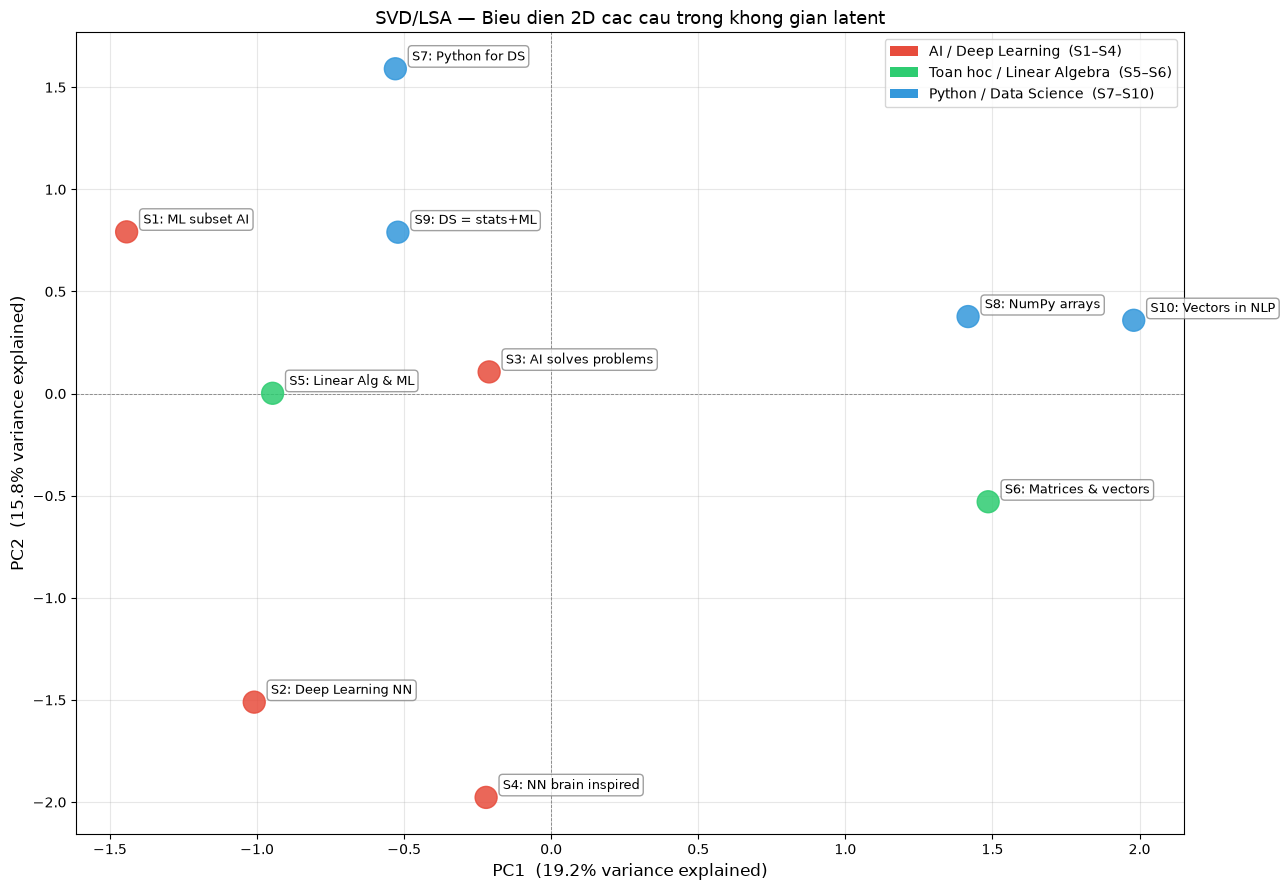

In [23]:
# Nhan chu de cho tung cau
topic_labels = ['AI/DL']*4 + ['Math']*2 + ['Python/DS']*4
color_map = {'AI/DL': '#e74c3c', 'Math': '#2ecc71', 'Python/DS': '#3498db'}
colors = [color_map[t] for t in topic_labels]

short_names = [
    'ML subset AI', 'Deep Learning NN', 'AI solves problems', 'NN brain inspired',
    'Linear Alg & ML', 'Matrices & vectors',
    'Python for DS', 'NumPy arrays', 'DS = stats+ML', 'Vectors in NLP'
]

fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=250, alpha=0.85, zorder=5)

for i, (x, y) in enumerate(coords):
    ax.annotate(
        f'S{i+1}: {short_names[i]}',
        (x, y),
        textcoords='offset points', xytext=(12, 6),
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75, edgecolor='gray')
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.6)
ax.set_xlabel(f'PC1  ({explained[0]*100:.1f}% variance explained)', fontsize=12)
ax.set_ylabel(f'PC2  ({explained[1]*100:.1f}% variance explained)', fontsize=12)
ax.set_title('SVD/LSA — Bieu dien 2D cac cau trong khong gian latent', fontsize=13)
ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#e74c3c', label='AI / Deep Learning  (S1–S4)'),
    Patch(facecolor='#2ecc71', label='Toan hoc / Linear Algebra  (S5–S6)'),
    Patch(facecolor='#3498db', label='Python / Data Science  (S7–S10)'),
]
ax.legend(handles=legend_elems, loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('svd_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

### 2.3 Đánh giá — Đồ thị Singular Values & Năng lượng tích lũy
(Phần này tương đương với việc chọn `k` trong nén ảnh — **Bonus**)

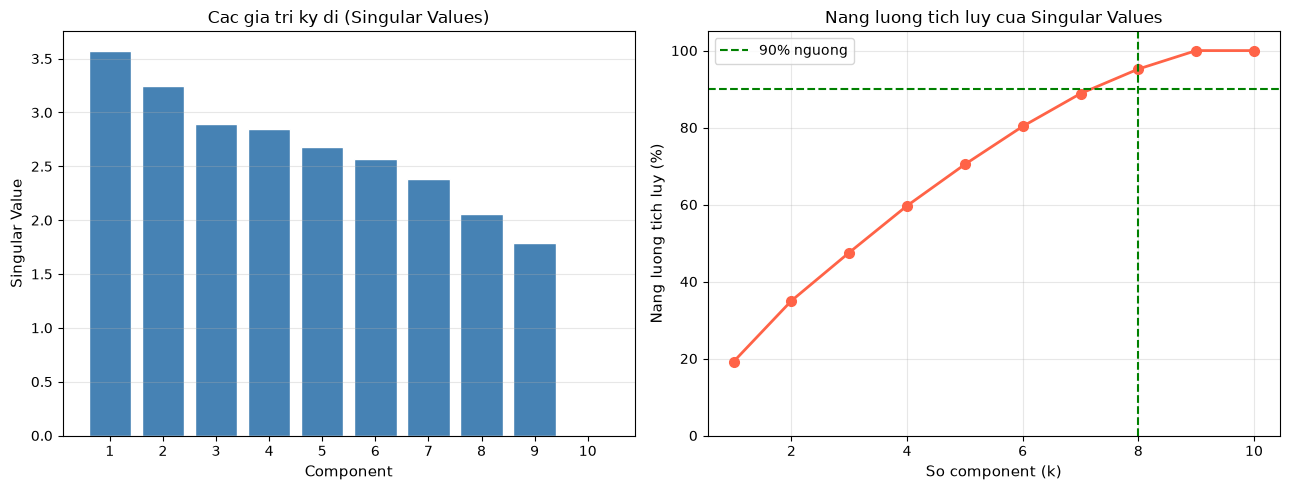

Can k = 8 component de giu >= 90% thong tin
Tong so tu trong vocab: 55 → giam xuong 8 chieu!


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Singular values
axes[0].bar(range(1, len(S_vals)+1), S_vals, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Component', fontsize=11)
axes[0].set_ylabel('Singular Value', fontsize=11)
axes[0].set_title('Cac gia tri ky di (Singular Values)', fontsize=12)
axes[0].set_xticks(range(1, min(len(S_vals), 15)+1))
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cumulative energy
cumulative = np.cumsum(S_vals**2) / np.sum(S_vals**2)
axes[1].plot(range(1, len(S_vals)+1), cumulative*100, 'o-', color='tomato', linewidth=2, markersize=7)
axes[1].axhline(90, color='green', linestyle='--', linewidth=1.5, label='90% nguong')
k_90 = int(np.argmax(cumulative >= 0.90)) + 1
axes[1].axvline(k_90, color='green', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('So component (k)', fontsize=11)
axes[1].set_ylabel('Nang luong tich luy (%)', fontsize=11)
axes[1].set_title('Nang luong tich luy cua Singular Values', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('singular_values.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Can k = {k_90} component de giu >= 90% thong tin')
print(f'Tong so tu trong vocab: {len(vocab)} → giam xuong {k_90} chieu!')

### 2.4 Nhận xét
- **Scatter 2D**: Các câu cùng chủ đề **nằm gần nhau** trên mặt phẳng 2D — SVD đã tự động phát hiện cấu trúc ngữ nghĩa ẩn (latent semantic).
- **PC1** thường ứng với chiều phân biệt chủ đề rộng nhất; **PC2** nắm bắt sự khác biệt thứ hai.
- Liên hệ với **PCA**: SVD của $X_c$ chính là PCA — các cột của $V^\top$ là *eigenvector* (principal components) của $X_c^\top X_c$.
- Trong AI: kỹ thuật này là nền tảng của **Word2Vec**, **Topic Modeling**, và các phương pháp giảm chiều như **t-SNE** hay **UMAP**.

---
# Bonus (+10%) — Bộ phân loại 1-NN dựa trên Cosine Similarity
Với mỗi câu test, tìm câu train **gần nhất** (cosine similarity cao nhất) và gán nhãn của câu đó.

In [36]:
def predict_1nn(query_vec, X_train, y_train):
    """Phan loai 1-NN dua tren cosine similarity."""
    q = query_vec.reshape(1, -1)
    sims = cosine_similarity(q, X_train)[0]
    nearest_idx = np.argmax(sims)
    return y_train[nearest_idx], float(sims[nearest_idx])

# Nhan chu de
topic_labels_list = ['AI/DL']*4 + ['Math']*2 + ['Python/DS']*4

# Danh gia Leave-One-Out (LOO-CV)
print('=== DANH GIA 1-NN — Leave-One-Out Cross Validation ===')
print(f'{"":-<70}')
correct = 0
for i in range(len(sentences)):
    X_train = np.delete(X, i, axis=0)
    y_train = topic_labels_list[:i] + topic_labels_list[i+1:]
    pred, score = predict_1nn(X[i], X_train, y_train)
    is_ok = (pred == topic_labels_list[i])
    correct += is_ok
    status = 'DUNG' if is_ok else 'SAI '
    print(f'  [{status}] S{i+1:02d}  Du doan: {pred:10s} | Nhan that: {topic_labels_list[i]:10s} | Score: {score:.4f}')
print(f'{"":-<70}')
print(f'Do chinh xac: {correct}/{len(sentences)} = {correct/len(sentences)*100:.1f}%')

=== DANH GIA 1-NN — Leave-One-Out Cross Validation ===
----------------------------------------------------------------------
  [SAI ] S01  Du doan: Math       | Nhan that: AI/DL      | Score: 0.4009
  [SAI ] S02  Du doan: Math       | Nhan that: AI/DL      | Score: 0.2673
  [DUNG] S03  Du doan: AI/DL      | Nhan that: AI/DL      | Score: 0.2887
  [DUNG] S04  Du doan: AI/DL      | Nhan that: AI/DL      | Score: 0.2500
  [SAI ] S05  Du doan: AI/DL      | Nhan that: Math       | Score: 0.4009
  [SAI ] S06  Du doan: Python/DS  | Nhan that: Math       | Score: 0.3162
  [SAI ] S07  Du doan: AI/DL      | Nhan that: Python/DS  | Score: 0.2357
  [SAI ] S08  Du doan: Math       | Nhan that: Python/DS  | Score: 0.2222
  [SAI ] S09  Du doan: Math       | Nhan that: Python/DS  | Score: 0.2673
  [SAI ] S10  Du doan: Math       | Nhan that: Python/DS  | Score: 0.3162
----------------------------------------------------------------------
Do chinh xac: 2/10 = 20.0%


**Nhận xét Bonus:**
- 1-NN Cosine đơn giản nhưng hiệu quả với BoW: câu cùng chủ đề dùng từ tương tự → cosine cao → phân loại đúng.
- Hạn chế: câu ngắn hoặc dùng ít từ chung với tập train sẽ khó phân loại chính xác.
- Đây là nền tảng của các hệ thống **retrieval-based** và **nearest-neighbor search** trong AI.